<div style="display: flex; align-items: center;">

  <!-- Logos -->
  <div style="white-space: nowrap;">
    <img 
      src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" 
      width="300"
      style="vertical-align: middle;"
    >
    <img 
      src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" 
      width="200"
      style="vertical-align: middle;"
    >
  </div>

  <!-- Texto -->
  <div style="margin-left: auto; margin-right: 100px; text-align: right;">
      <p style="margin: 0;"><b>CaixaBank · Advanced Analytics Program</b></p>
      <p style="margin: 0;"><b>Model Risk & Data Science Training</b></p>
      <p style="margin: 0;">Intelligence Data Science and Artificial Intelligence (IDEAI)</p>
  </div>

</div>

# 🔎 **Evaluación e Interpretación de Modelos para Auditores Bancarios**

Este notebook desarrolla de forma práctica y aplicada cómo **evaluar, comparar, interpretar y justificar modelos predictivos** en un contexto de auditoría bancaria.

El objetivo no es solo obtener un modelo con buena métrica, sino poder responder preguntas clave de auditoría:

- ¿El modelo discrimina correctamente entre clientes/eventos buenos y malos?
- ¿Está calibrado el score o la probabilidad estimada?
- ¿Qué umbral de decisión debe utilizarse según el coste del error?
- ¿Es estable el modelo frente a nuevos datos?
- ¿Qué variables explican las predicciones globalmente?
- ¿Por qué un cliente, operación o alerta concreta recibió una predicción determinada?
- ¿Cómo documentar evidencias para validación, auditoría interna, compliance y gobierno del modelo?

Incluye modelos XAI como **permutation importance**, **PDP**, **ICE**, **LIME conceptual** y especialmente **SHAP values**.

## 1. FUNDAMENTOS DE EVALUACIÓN DE MODELOS

En banca, evaluar un modelo no consiste únicamente en calcular un accuracy. Muchos problemas bancarios son **desbalanceados**, tienen **costes asimétricos** y están sometidos a exigencias de **explicabilidad, trazabilidad, estabilidad y control de sesgos**.

Ejemplos:

| Caso bancario | Clase positiva habitual | Problema principal |
|---|---:|---|
| Default crediticio | Cliente impaga | Clase minoritaria y coste alto |
| Fraude transaccional | Operación fraudulenta | Muy desbalanceado |
| AML / blanqueo | Alerta sospechosa real | Falsos positivos operativos |
| Churn bancario | Cliente abandona | Umbral orientado a retención |
| Riesgo operativo | Incidencia material | Baja frecuencia, alto impacto |

### 1.1 ¿Qué significa evaluar un modelo?

La evaluación debe cubrir cuatro dimensiones:

1. **Capacidad predictiva:** si el modelo acierta y discrimina correctamente.
2. **Calibración:** si las probabilidades estimadas son realistas.
3. **Robustez y estabilidad:** si el modelo mantiene comportamiento en nuevos datos.
4. **Interpretabilidad:** si se puede explicar qué variables influyen y por qué.

En auditoría bancaria, un modelo puede tener buen AUC pero no ser aceptable si:

- no está calibrado;
- discrimina injustificadamente por segmentos;
- no es interpretable;
- no tiene documentación suficiente;
- usa variables proxy de información sensible;
- presenta drift temporal;
- genera decisiones no defendibles ante supervisores o clientes.

### 1.2 Tipos de evaluación

| Tipo de evaluación | Pregunta | Ejemplos de métricas |
|---|---|---|
| Clasificación binaria | ¿Detecta bien eventos 0/1? | Accuracy, precision, recall, F1, ROC-AUC, PR-AUC |
| Probabilidad / scoring | ¿La probabilidad es fiable? | Brier score, calibration curve, log-loss |
| Ranking | ¿Ordena bien el riesgo? | AUC, Gini, lift, KS |
| Segmentación | ¿Funciona igual por grupos? | Métricas por segmento, fairness checks |
| Estabilidad | ¿Se degrada con nuevos datos? | PSI, drift, comparación temporal |
| Interpretabilidad | ¿Podemos justificarlo? | SHAP, PDP, importancia de variables |

### 1.3 Riesgos típicos en banca

| Riesgo | Descripción | Control recomendado |
|---|---|---|
| Data leakage | El modelo usa información futura o no disponible en decisión | Revisión temporal de variables |
| Overfitting | Excelente en train, pobre en test | Validación cruzada, holdout temporal |
| Desbalanceo extremo | El modelo ignora la clase minoritaria | PR-AUC, recall, pesos de clase |
| Mala calibración | Probabilidades demasiado optimistas/pesimistas | Calibration curve, Brier score |
| Falta de explicabilidad | No se puede justificar la decisión | SHAP, documentación, variables auditables |
| Drift | Cambia la población o el comportamiento | PSI, monitorización periódica |
| Variables proxy | Variables aparentemente neutras capturan información sensible | Revisión experta y segmentada |

## 2. PREPARACIÓN DEL ENTORNO

El notebook utiliza librerías estándar de ciencia de datos. SHAP puede no estar instalado en todos los entornos; por eso se incluye instalación opcional y un bloque robusto que permite continuar aunque no esté disponible.

In [1]:
# ============================================================
# 1. Librerías base
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    classification_report, brier_score_loss, log_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# ============================================================
# 2. Carga opcional de SHAP
# ============================================================
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP disponible")
except Exception as e:
    SHAP_AVAILABLE = False
    print("SHAP no está disponible en este entorno.")
    print("Para instalarlo: pip install shap")

SHAP disponible


## 3. CARGA DE DATOS DE AUDITORÍA BANCARIA

En este notebook se trabaja con el fichero `auditoria_bancaria_desbalanceada.csv`, generado en el script introductorio del curso.

La variable objetivo es `riesgo_auditoria`, que identifica si una operación presenta riesgo relevante para revisión/auditoría.

Variables principales del dataset:

| Variable | Significado |
|---|---|
| importe_operacion | Importe individual de la operación |
| saldo_medio_cliente | Saldo medio del cliente |
| num_operaciones_30d | Número de operaciones en los últimos 30 días |
| importe_total_30d | Importe total operado en los últimos 30 días |
| antiguedad_cliente_meses | Antigüedad del cliente en meses |
| score_crediticio | Score crediticio interno o externo |
| ratio_ingresos_deuda | Relación entre ingresos y deuda |
| num_alertas_previas | Número de alertas previas del cliente |
| dias_desde_ultima_revision | Días desde la última revisión de auditoría |
| porcentaje_operaciones_internacionales | Porcentaje de operativa internacional |
| canal_operacion | Canal de la operación |
| tipo_cliente | Tipo de cliente |
| pais_riesgo | Nivel de riesgo del país |
| producto | Producto bancario asociado |
| segmento_riesgo_cliente | Segmento interno de riesgo |
| riesgo_auditoria | Variable objetivo binaria |


In [4]:
# ============================================================
# Carga del dataset de auditoría bancaria
# ============================================================
RUTA_CSV = "../../data/auditoria_bancaria_desbalanceada.csv"

try:
    df = pd.read_csv(RUTA_CSV)
except FileNotFoundError:
    df = pd.read_csv("/mnt/data/auditoria_bancaria_desbalanceada.csv")

# Eliminamos identificador técnico si existe, porque no debe usarse como predictor
if "id_operacion" in df.columns:
    df = df.drop(columns=["id_operacion"])

# Aseguramos que la variable objetivo sea numérica binaria
df["riesgo_auditoria"] = df["riesgo_auditoria"].astype(int)

df.head()


,importe_operacion,saldo_medio_cliente,num_operaciones_30d,importe_total_30d,antiguedad_cliente_meses,score_crediticio,ratio_ingresos_deuda,num_alertas_previas,dias_desde_ultima_revision,porcentaje_operaciones_internacionales,canal_operacion,tipo_cliente,pais_riesgo,producto,segmento_riesgo_cliente,riesgo_auditoria
0,233.39,11739.05,17,3085.27,25.0,763.0,0.309,1,31.0,0.003,oficina,particular,bajo,prestamo,medio,0
1,829.72,411.47,15,10457.08,80.0,665.0,0.248,1,37.0,0.007,web,particular,bajo,transferencia,medio,0
2,176.14,2928.34,23,5525.19,21.0,610.0,0.257,0,269.0,0.439,cajero,particular,alto,tarjeta,medio,1
3,2141.27,3579.99,16,2347.29,71.0,776.0,0.211,0,326.0,0.120,web,pyme,bajo,cuenta,alto,0
4,1039.73,1938.84,16,9070.86,27.0,626.0,0.278,0,150.0,0.179,app,particular,bajo,cuenta,bajo,0


In [5]:
print("Dimensiones:", df.shape)
print("Tasa de riesgo de auditoría:", df["riesgo_auditoria"].mean().round(4))
print("Distribución de la variable objetivo:")
print(df["riesgo_auditoria"].value_counts(normalize=True).round(4))

df.describe(include="all")

Dimensiones: (15000, 16)
Tasa de riesgo de auditoría: 0.0632
Distribución de la variable objetivo:
riesgo_auditoria
0    0.9368
1    0.0632
Name: proportion, dtype: float64


,importe_operacion,saldo_medio_cliente,num_operaciones_30d,importe_total_30d,antiguedad_cliente_meses,score_crediticio,ratio_ingresos_deuda,num_alertas_previas,dias_desde_ultima_revision,porcentaje_operaciones_internacionales,canal_operacion,tipo_cliente,pais_riesgo,producto,segmento_riesgo_cliente,riesgo_auditoria
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000,15000,15000,15000,15000,15000.00000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,4,3,5,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,app,particular,bajo,tarjeta,bajo,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6309,10087,11673,4824,9746,NaN
mean,1459.922872,9824.272609,17.932133,11404.111911,62.701600,680.301200,0.285775,0.445000,107.889667,0.130876,NaN,NaN,NaN,NaN,NaN,0.06320
std,2694.705284,12503.778828,4.251047,22673.629097,33.827017,85.030305,0.152676,0.661265,107.334137,0.104906,NaN,NaN,NaN,NaN,NaN,0.24333
min,5.000000,122.350000,4.000000,0.000000,3.000000,356.000000,0.005000,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.00000
25%,333.542500,3075.897500,15.000000,2147.552500,38.000000,623.000000,0.168000,0.000000,32.000000,0.050000,NaN,NaN,NaN,NaN,NaN,0.00000
50%,732.075000,5977.365000,18.000000,5563.940000,57.000000,680.000000,0.266000,0.000000,75.000000,0.104500,NaN,NaN,NaN,NaN,NaN,0.00000
75%,1610.820000,11731.487500,21.000000,12193.982500,81.000000,738.000000,0.384000,1.000000,151.000000,0.187000,NaN,NaN,NaN,NaN,NaN,0.00000


## 4. PARTICIÓN TRAIN / TEST

En un caso real de auditoría bancaria, si existe una fecha de operación, sería recomendable usar una partición temporal para evitar leakage. En este dataset base no se incluye fecha explícita, por lo que usamos partición estratificada para mantener la proporción de operaciones con riesgo en train y test.


In [6]:
X = df.drop(columns=["riesgo_auditoria"])
y = df["riesgo_auditoria"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Riesgo auditoría train:", y_train.mean().round(4))
print("Riesgo auditoría test:", y_test.mean().round(4))

Train: (10500, 15) Test: (4500, 15)
Riesgo auditoría train: 0.0632
Riesgo auditoría test: 0.0631


## 5. PIPELINE DE PREPROCESAMIENTO

Para evitar errores de auditoría y leakage, todo el preprocesamiento debe estar dentro de un `Pipeline`:

- imputación de missing values;
- escalado de variables numéricas cuando proceda;
- one-hot encoding de variables categóricas;
- entrenamiento del modelo.

Esto garantiza que las transformaciones se aprenden solo con train y se aplican después a test.

In [7]:
num_vars = X.select_dtypes(include=[np.number]).columns.tolist()
cat_vars = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_preprocess, num_vars),
    ("cat", categorical_preprocess, cat_vars)
])

print("Variables numéricas:", num_vars)
print("Variables categóricas:", cat_vars)

Variables numéricas: ['importe_operacion', 'saldo_medio_cliente', 'num_operaciones_30d', 'importe_total_30d', 'antiguedad_cliente_meses', 'score_crediticio', 'ratio_ingresos_deuda', 'num_alertas_previas', 'dias_desde_ultima_revision', 'porcentaje_operaciones_internacionales']
Variables categóricas: ['canal_operacion', 'tipo_cliente', 'pais_riesgo', 'producto', 'segmento_riesgo_cliente']


## 6. ENTRENAMIENTO DE MODELOS BASE

Compararemos tres modelos:

1. **Regresión logística:** modelo interpretable y baseline regulatorio frecuente.
2. **Random Forest:** modelo no lineal robusto.
3. **Gradient Boosting:** modelo potente y más próximo a familias XGBoost / CatBoost.

In [8]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=6,
        min_samples_leaf=30,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=180,
        learning_rate=0.045,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

pipelines = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])
    pipe.fit(X_train, y_train)
    pipelines[nombre] = pipe

print("Modelos entrenados:", list(pipelines.keys()))

Modelos entrenados: ['Logistic Regression', 'Random Forest', 'Gradient Boosting']


## 7. MÉTRICAS DE CLASIFICACIÓN

### 7.1 Matriz de confusión

La matriz de confusión es esencial porque muestra los errores concretos:

| Concepto | Interpretación bancaria |
|---|---|
| True Negative | Cliente no default correctamente aprobado |
| False Positive | Cliente sano marcado como riesgoso |
| False Negative | Cliente que defaulta pero el modelo no detecta |
| True Positive | Cliente default correctamente detectado |

En riesgo de crédito, normalmente un **false negative** puede ser más costoso que un false positive.

In [9]:
def evaluar_modelo(nombre, modelo, X_test, y_test, threshold=0.5):
    y_prob = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "modelo": nombre,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
        "brier": brier_score_loss(y_test, y_prob),
        "log_loss": log_loss(y_test, y_prob)
    }

resultados = pd.DataFrame([
    evaluar_modelo(nombre, pipe, X_test, y_test)
    for nombre, pipe in pipelines.items()
]).sort_values("roc_auc", ascending=False)

resultados.round(4)

,modelo,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,brier,log_loss
0,Logistic Regression,0.5,0.9238,0.4491,0.9155,0.6025,0.9504,0.8593,0.0557,0.1919
2,Gradient Boosting,0.5,0.9624,0.9600,0.4225,0.5868,0.9466,0.8023,0.0274,0.1035
1,Random Forest,0.5,0.8878,0.3419,0.8415,0.4863,0.9283,0.6734,0.1012,0.3546


### 7.2 Interpretación de métricas

| Métrica | Qué mide | Cuándo usarla |
|---|---|---|
| Accuracy | Proporción total de aciertos | Solo si clases equilibradas |
| Precision | De los marcados como riesgo, cuántos realmente lo son | Cuando los falsos positivos son caros |
| Recall / Sensitivity | De los defaults reales, cuántos detectamos | Cuando los falsos negativos son críticos |
| F1 | Balance entre precision y recall | Cuando hay desbalanceo |
| ROC-AUC | Capacidad de ranking global | Scoring general |
| PR-AUC | Calidad sobre clase positiva | Eventos raros: fraude, AML, default |
| Brier score | Error cuadrático de probabilidad | Calibración |
| Log-loss | Penaliza probabilidades erróneas confiadas | Modelos probabilísticos |

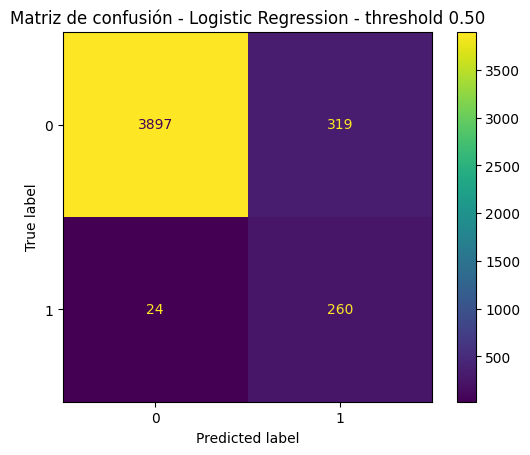

              precision    recall  f1-score   support

           0     0.9939    0.9243    0.9578      4216
           1     0.4491    0.9155    0.6025       284

    accuracy                         0.9238      4500
   macro avg     0.7215    0.9199    0.7802      4500
weighted avg     0.9595    0.9238    0.9354      4500



In [10]:
# Matriz de confusión del mejor modelo por ROC-AUC
mejor_nombre = resultados.iloc[0]["modelo"]
mejor_modelo = pipelines[mejor_nombre]

y_prob_best = mejor_modelo.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_best >= 0.5).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title(f"Matriz de confusión - {mejor_nombre} - threshold 0.50")
plt.show()

print(classification_report(y_test, y_pred_best, digits=4))

## 8. CURVAS ROC Y PRECISION-RECALL

### 8.1 Curva ROC

La curva ROC compara sensibilidad frente a tasa de falsos positivos para todos los umbrales. Es útil para medir capacidad de ranking.

### 8.2 Curva Precision-Recall

La curva Precision-Recall es especialmente importante cuando la clase positiva es rara. En banca suele ser más informativa para fraude, AML o default de baja frecuencia.

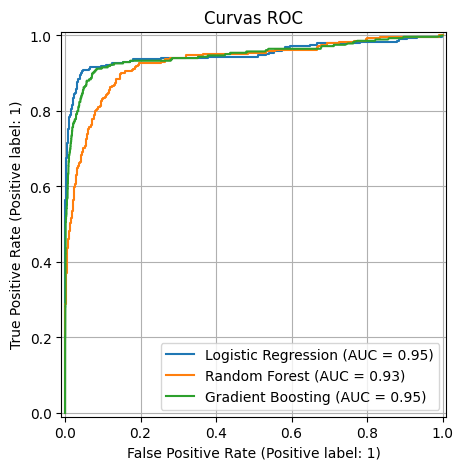

In [11]:
plt.figure(figsize=(7, 5))
for nombre, pipe in pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=nombre, ax=plt.gca())
plt.title("Curvas ROC")
plt.grid(True)
plt.show()

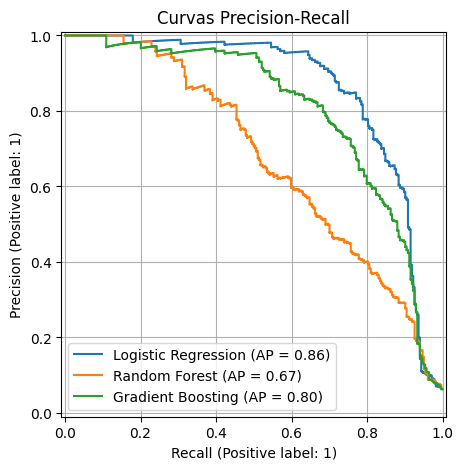

In [12]:
plt.figure(figsize=(7, 5))
for nombre, pipe in pipelines.items():
    PrecisionRecallDisplay.from_estimator(pipe, X_test, y_test, name=nombre, ax=plt.gca())
plt.title("Curvas Precision-Recall")
plt.grid(True)
plt.show()

## 9. SELECCIÓN DEL UMBRAL DE DECISIÓN

El umbral 0.50 rara vez es óptimo en banca. Debe elegirse según:

- coste esperado del false positive;
- coste esperado del false negative;
- capacidad operativa de revisión manual;
- política de apetito al riesgo;
- sensibilidad regulatoria;
- impacto comercial.

Ejemplo: si revisar manualmente un expediente cuesta poco pero conceder crédito a un cliente que defaulta cuesta mucho, se puede bajar el umbral para aumentar recall.

In [13]:
def tabla_thresholds(y_true, y_prob, thresholds=np.arange(0.05, 0.96, 0.05)):
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        rows.append({
            "threshold": t,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "tasa_alertas": y_pred.mean()
        })
    return pd.DataFrame(rows)

tabla_umbral = tabla_thresholds(y_test, y_prob_best)
tabla_umbral.round(4).head(10)

,threshold,TP,FP,FN,TN,precision,recall,f1,tasa_alertas
0,0.05,268,1716,16,2500,0.1351,0.9437,0.2363,0.4409
1,0.10,267,1273,17,2943,0.1734,0.9401,0.2928,0.3422
2,0.15,266,1017,18,3199,0.2073,0.9366,0.3395,0.2851
3,0.20,266,857,18,3359,0.2369,0.9366,0.3781,0.2496
4,0.25,265,729,19,3487,0.2666,0.9331,0.4147,0.2209
5,0.30,263,625,21,3591,0.2962,0.9261,0.4488,0.1973
6,0.35,262,520,22,3696,0.3350,0.9225,0.4916,0.1738
7,0.40,261,451,23,3765,0.3666,0.9190,0.5241,0.1582
8,0.45,260,393,24,3823,0.3982,0.9155,0.5550,0.1451
9,0.50,260,319,24,3897,0.4491,0.9155,0.6025,0.1287


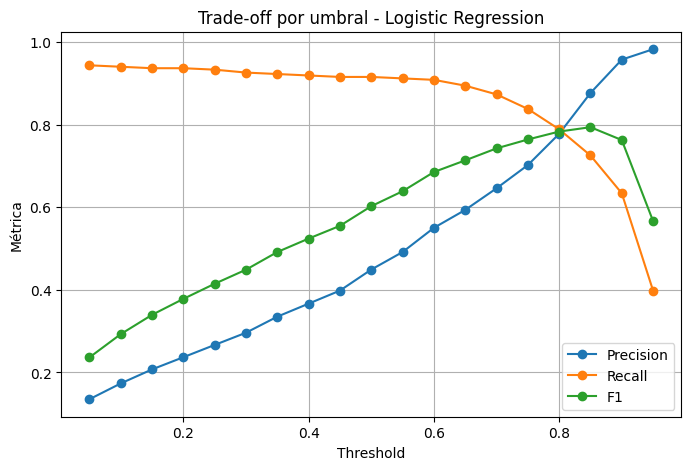

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(tabla_umbral["threshold"], tabla_umbral["precision"], marker="o", label="Precision")
plt.plot(tabla_umbral["threshold"], tabla_umbral["recall"], marker="o", label="Recall")
plt.plot(tabla_umbral["threshold"], tabla_umbral["f1"], marker="o", label="F1")
plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.title(f"Trade-off por umbral - {mejor_nombre}")
plt.grid(True)
plt.legend()
plt.show()

### 9.1 Umbral basado en coste esperado

Una forma defendible ante auditoría es seleccionar el umbral que minimiza el coste esperado.

Ejemplo:

- False Positive: revisar o rechazar un cliente bueno. Coste = 500 €
- False Negative: aprobar cliente que acaba en default. Coste = 8.000 €

El coste total aproximado sería:

$$Coste = FP \cdot C_{FP} + FN \cdot C_{FN}$$

In [15]:
COSTE_FP = 500
COSTE_FN = 8000

tabla_costes = tabla_umbral.copy()
tabla_costes["coste_total"] = tabla_costes["FP"] * COSTE_FP + tabla_costes["FN"] * COSTE_FN

tabla_costes.sort_values("coste_total").head(10).round(2)

,threshold,TP,FP,FN,TN,precision,recall,f1,tasa_alertas,coste_total
11,0.60,258,211,26,4005,0.55,0.91,0.69,0.10,313500
12,0.65,254,174,30,4042,0.59,0.89,0.71,0.10,327000
10,0.55,259,268,25,3948,0.49,0.91,0.64,0.12,334000
9,0.50,260,319,24,3897,0.45,0.92,0.60,0.13,351500
13,0.70,248,136,36,4080,0.65,0.87,0.74,0.09,356000
8,0.45,260,393,24,3823,0.40,0.92,0.55,0.15,388500
7,0.40,261,451,23,3765,0.37,0.92,0.52,0.16,409500
14,0.75,238,101,46,4115,0.70,0.84,0.76,0.08,418500
6,0.35,262,520,22,3696,0.34,0.92,0.49,0.17,436000
5,0.30,263,625,21,3591,0.30,0.93,0.45,0.20,480500


Umbral óptimo según costes: 0.6


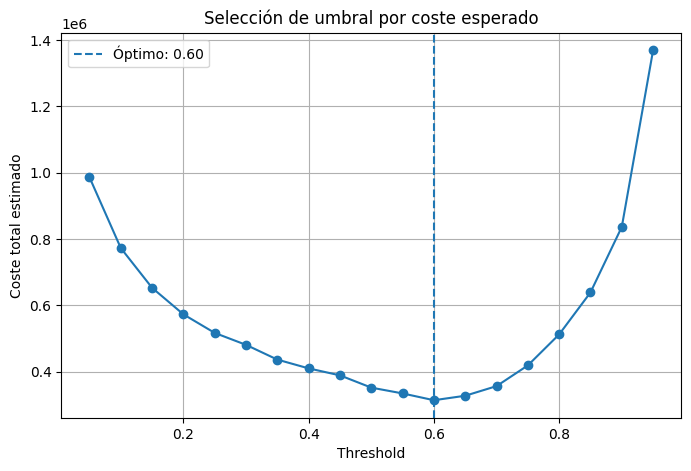

In [16]:
umbral_optimo = tabla_costes.sort_values("coste_total").iloc[0]["threshold"]
print("Umbral óptimo según costes:", round(float(umbral_optimo), 2))

plt.figure(figsize=(8, 5))
plt.plot(tabla_costes["threshold"], tabla_costes["coste_total"], marker="o")
plt.axvline(umbral_optimo, linestyle="--", label=f"Óptimo: {umbral_optimo:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Coste total estimado")
plt.title("Selección de umbral por coste esperado")
plt.grid(True)
plt.legend()
plt.show()

## 10. CALIBRACIÓN DE PROBABILIDADES

Un modelo puede ordenar bien a los clientes pero estimar mal las probabilidades.

Ejemplo:

- Modelo AUC alto: separa bien riesgo bajo y alto.
- Pero si predice 30% de default para un grupo donde realmente defaulta el 12%, está mal calibrado.

En banca, la calibración es clave para:

- provisiones;
- pricing;
- capital económico;
- límites de aprobación;
- reporting regulatorio;
- decisiones automatizadas.

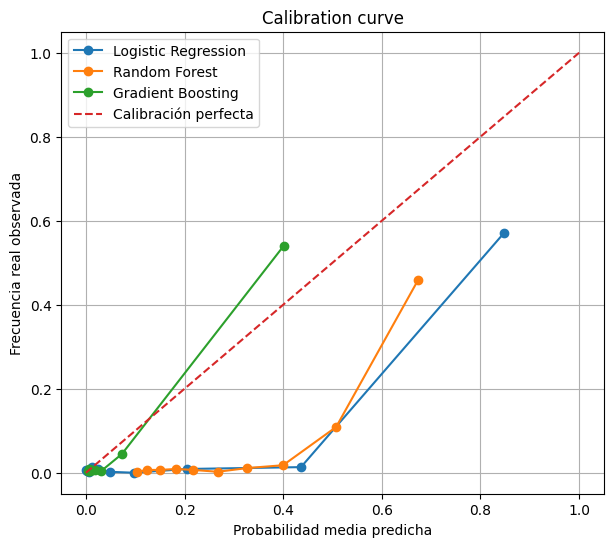

In [17]:
plt.figure(figsize=(7, 6))
for nombre, pipe in pipelines.items():
    prob = pipe.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=nombre)

plt.plot([0, 1], [0, 1], linestyle="--", label="Calibración perfecta")
plt.xlabel("Probabilidad media predicha")
plt.ylabel("Frecuencia real observada")
plt.title("Calibration curve")
plt.grid(True)
plt.legend()
plt.show()

In [18]:
calibracion = resultados[["modelo", "brier", "log_loss", "roc_auc", "pr_auc"]].copy()
calibracion.sort_values("brier").round(4)

,modelo,brier,log_loss,roc_auc,pr_auc
2,Gradient Boosting,0.0274,0.1035,0.9466,0.8023
0,Logistic Regression,0.0557,0.1919,0.9504,0.8593
1,Random Forest,0.1012,0.3546,0.9283,0.6734


### 10.1 Calibración con Platt Scaling o Isotonic

`CalibratedClassifierCV` permite calibrar modelos con:

- **sigmoid:** Platt scaling, más estable con pocos datos;
- **isotonic:** más flexible, pero puede sobreajustar si hay pocos datos.

En auditoría se debe documentar:

- datos usados para calibrar;
- fecha de calibración;
- método usado;
- mejora en Brier score y curva de calibración;
- periodo de monitorización.

In [19]:
# Ejemplo: calibrar Random Forest con método sigmoid
rf_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=250,
        max_depth=6,
        min_samples_leaf=30,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

rf_calibrado = CalibratedClassifierCV(rf_base, method="sigmoid", cv=3)
rf_calibrado.fit(X_train, y_train)

prob_rf = pipelines["Random Forest"].predict_proba(X_test)[:, 1]
prob_rf_cal = rf_calibrado.predict_proba(X_test)[:, 1]

print("Brier RF original:", round(brier_score_loss(y_test, prob_rf), 4))
print("Brier RF calibrado:", round(brier_score_loss(y_test, prob_rf_cal), 4))
print("AUC RF original:", round(roc_auc_score(y_test, prob_rf), 4))
print("AUC RF calibrado:", round(roc_auc_score(y_test, prob_rf_cal), 4))

Brier RF original: 0.1012
Brier RF calibrado: 0.0325
AUC RF original: 0.9283
AUC RF calibrado: 0.9299


## 11. VALIDACIÓN CRUZADA

La validación cruzada permite estimar la variabilidad del rendimiento. En banca, además, se recomienda validación temporal cuando exista histórico suficiente.

In [20]:
scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for nombre, pipe in pipelines.items():
    cv_result = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"modelo": nombre}
    for metric in scoring.keys():
        values = cv_result[f"test_{metric}"]
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std()
    cv_rows.append(row)

pd.DataFrame(cv_rows).round(4)

,modelo,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std
0,Logistic Regression,0.9659,0.0097,0.8909,0.0149,0.5949,0.0197,0.9458,0.0074,0.4342,0.0196
1,Random Forest,0.9461,0.0128,0.7262,0.0373,0.5214,0.0217,0.8840,0.0194,0.3701,0.0213
2,Gradient Boosting,0.9610,0.0093,0.8411,0.0251,0.6326,0.0427,0.4758,0.0463,0.9498,0.0323


## 12. ESTABILIDAD DEL MODELO: PSI

El **Population Stability Index (PSI)** compara la distribución de una variable o score entre dos periodos.

Uso habitual:

- comparar train vs test;
- comparar mes actual vs mes de desarrollo;
- detectar drift del score;
- monitorizar variables críticas.

Interpretación habitual:

| PSI | Interpretación |
|---:|---|
| < 0.10 | Estable |
| 0.10 - 0.25 | Cambio moderado, revisar |
| > 0.25 | Cambio relevante, posible recalibración/reentrenamiento |

In [21]:
def calcular_psi(expected, actual, bins=10, eps=1e-6):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    # Cortes por cuantiles sobre expected
    quantiles = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(expected, quantiles))
    cut_points[0] = -np.inf
    cut_points[-1] = np.inf

    expected_bins = pd.cut(expected, bins=cut_points, include_lowest=True)
    actual_bins = pd.cut(actual, bins=cut_points, include_lowest=True)

    expected_dist = expected_bins.value_counts(normalize=True).sort_index().replace(0, eps)
    actual_dist = actual_bins.value_counts(normalize=True).sort_index().replace(0, eps)

    psi_values = (actual_dist - expected_dist) * np.log(actual_dist / expected_dist)
    psi_table = pd.DataFrame({
        "bin": expected_dist.index.astype(str),
        "expected_pct": expected_dist.values,
        "actual_pct": actual_dist.values,
        "psi": psi_values.values
    })
    return psi_table["psi"].sum(), psi_table

score_train = mejor_modelo.predict_proba(X_train)[:, 1]
score_test = mejor_modelo.predict_proba(X_test)[:, 1]

psi_score, psi_tabla = calcular_psi(score_train, score_test, bins=10)
print("PSI del score:", round(psi_score, 4))
psi_tabla.round(4)

PSI del score: 0.0028


,bin,expected_pct,actual_pct,psi
0,"(-inf, 0.0017]",0.1,0.1056,0.0003
1,"(0.0017, 0.0047]",0.1,0.1138,0.0018
2,"(0.0047, 0.00977]",0.1,0.1000,0.0000
3,"(0.00977, 0.0192]",0.1,0.0964,0.0001
4,"(0.0192, 0.0368]",0.1,0.0989,0.0000
5,"(0.0368, 0.073]",0.1,0.0991,0.0000
6,"(0.073, 0.148]",0.1,0.0993,0.0000
7,"(0.148, 0.31]",0.1,0.0947,0.0003
8,"(0.31, 0.642]",0.1,0.0958,0.0002
9,"(0.642, inf]",0.1,0.0964,0.0001


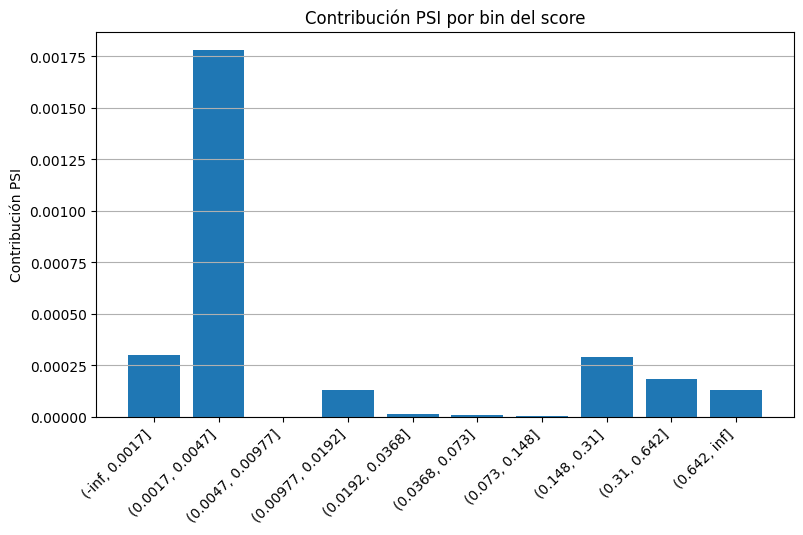

In [22]:
plt.figure(figsize=(9, 5))
plt.bar(range(len(psi_tabla)), psi_tabla["psi"])
plt.xticks(range(len(psi_tabla)), psi_tabla["bin"], rotation=45, ha="right")
plt.ylabel("Contribución PSI")
plt.title("Contribución PSI por bin del score")
plt.grid(axis="y")
plt.show()

## 13. INTERPRETABILIDAD GLOBAL

La interpretabilidad global responde:

> ¿Qué variables son más importantes para el comportamiento general del modelo?

Técnicas frecuentes:

| Técnica | Qué aporta | Limitación |
|---|---|---|
| Coeficientes | Dirección e intensidad en modelos lineales | Requiere escalado e independencia razonable |
| Importancia Gini / impurity | Importancia interna en árboles | Sesgo hacia variables con más cortes |
| Permutation importance | Caída de métrica al permutar una variable | Coste computacional, sensible a correlación |
| PDP | Efecto medio de una variable | Puede ocultar heterogeneidad |
| ICE | Efecto individual de una variable | Puede ser visualmente denso |
| SHAP global | Contribución media absoluta por variable | Más costoso, requiere cuidado en interpretación |

### 13.1 Recuperar nombres de variables transformadas

Cuando usamos `ColumnTransformer`, las variables categóricas se expanden mediante one-hot encoding. Para interpretar modelos, necesitamos recuperar los nombres finales.

In [23]:
def get_feature_names_from_pipeline(pipe):
    pre = pipe.named_steps["preprocessor"]
    names = []

    # Numéricas
    names.extend(num_vars)

    # Categóricas one-hot
    ohe = pre.named_transformers_["cat"].named_steps["onehot"]
    cat_names = ohe.get_feature_names_out(cat_vars).tolist()
    names.extend(cat_names)
    return names

feature_names = get_feature_names_from_pipeline(mejor_modelo)
feature_names[:10], len(feature_names)

(['importe_operacion',
  'saldo_medio_cliente',
  'num_operaciones_30d',
  'importe_total_30d',
  'antiguedad_cliente_meses',
  'score_crediticio',
  'ratio_ingresos_deuda',
  'num_alertas_previas',
  'dias_desde_ultima_revision',
  'porcentaje_operaciones_internacionales'],
 30)

### 13.2 Coeficientes de regresión logística

En modelos lineales, el signo del coeficiente indica la dirección:

- coeficiente positivo: aumenta la probabilidad estimada de default;
- coeficiente negativo: reduce la probabilidad estimada de default.

Para variables escaladas, la magnitud es comparable aproximadamente.

In [24]:
log_pipe = pipelines["Logistic Regression"]
log_features = get_feature_names_from_pipeline(log_pipe)
coefs = log_pipe.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "variable": log_features,
    "coeficiente": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

coef_df.head(15).round(4)

,variable,coeficiente,abs_coef
19,pais_riesgo_alto,2.3577,2.3577
27,segmento_riesgo_cliente_alto,2.0467,2.0467
20,pais_riesgo_bajo,-2.0209,2.0209
28,segmento_riesgo_cliente_bajo,-1.7888,1.7888
10,canal_operacion_api,1.5476,1.5476
16,tipo_cliente_empresa,1.2347,1.2347
7,num_alertas_previas,1.0960,1.0960
5,score_crediticio,-1.0154,1.0154
26,producto_transferencia,0.9872,0.9872
9,porcentaje_operaciones_internacionales,0.9635,0.9635


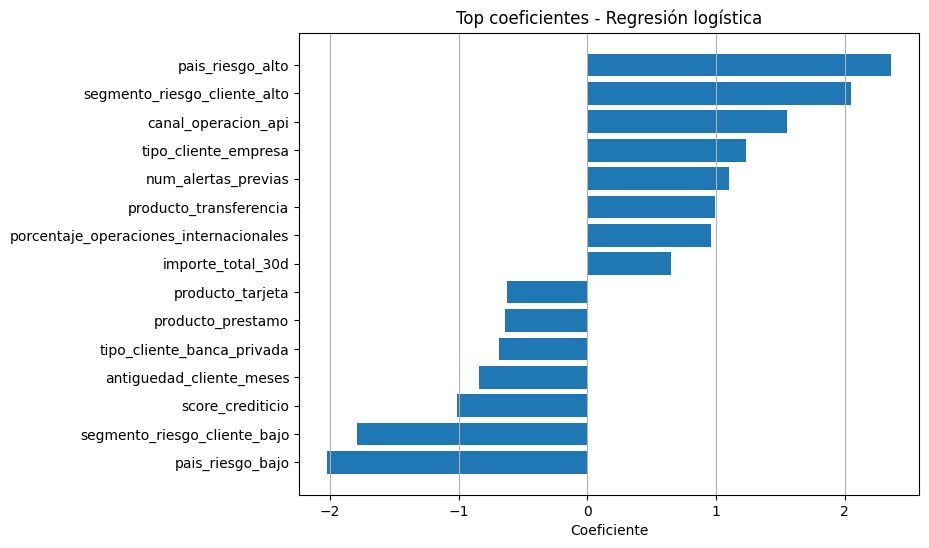

In [25]:
plt.figure(figsize=(8, 6))
top_coef = coef_df.head(15).sort_values("coeficiente")
plt.barh(top_coef["variable"], top_coef["coeficiente"])
plt.xlabel("Coeficiente")
plt.title("Top coeficientes - Regresión logística")
plt.grid(axis="x")
plt.show()

### 13.3 Permutation importance

La importancia por permutación mide cuánto empeora la métrica al romper la relación entre una variable y el objetivo.

Ventajas:

- sirve para cualquier modelo;
- se calcula sobre test;
- es más defendible que la importancia interna de árboles.

Precauciones:

- si dos variables están muy correlacionadas, la importancia puede repartirse;
- depende de la métrica elegida;
- debe calcularse sobre datos no usados para entrenar.

In [26]:
perm = permutation_importance(
    mejor_modelo,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "variable": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

perm_df.round(4)

,variable,importance_mean,importance_std
12,pais_riesgo,0.0515,0.0024
7,num_alertas_previas,0.0506,0.0038
14,segmento_riesgo_cliente,0.0397,0.0027
9,porcentaje_operaciones_internacionales,0.0308,0.0025
5,score_crediticio,0.0269,0.0036
4,antiguedad_cliente_meses,0.0189,0.0020
3,importe_total_30d,0.0150,0.0013
13,producto,0.0089,0.0017
11,tipo_cliente,0.0053,0.0007
10,canal_operacion,0.0045,0.0009


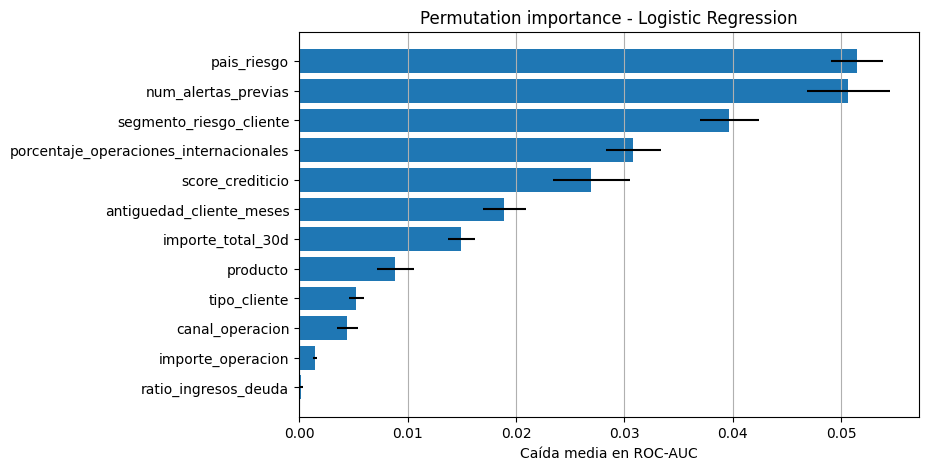

In [27]:
plt.figure(figsize=(8, 5))
top_perm = perm_df.head(12).sort_values("importance_mean")
plt.barh(top_perm["variable"], top_perm["importance_mean"], xerr=top_perm["importance_std"])
plt.xlabel("Caída media en ROC-AUC")
plt.title(f"Permutation importance - {mejor_nombre}")
plt.grid(axis="x")
plt.show()

## 14. PDP E ICE

### 14.1 Partial Dependence Plot

El PDP muestra el efecto medio de una variable sobre la predicción manteniendo el resto de variables como están.

### 14.2 Individual Conditional Expectation

ICE muestra curvas individuales. Es útil para detectar si el efecto de una variable no es homogéneo entre clientes.

En auditoría, PDP e ICE ayudan a responder:

- ¿el modelo reacciona de forma razonable ante más deuda?
- ¿más días de mora siempre aumentan el riesgo?
- ¿hay saltos extraños que indiquen sobreajuste?

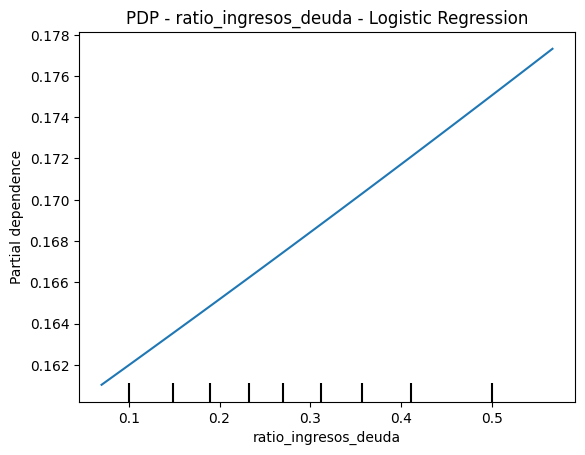

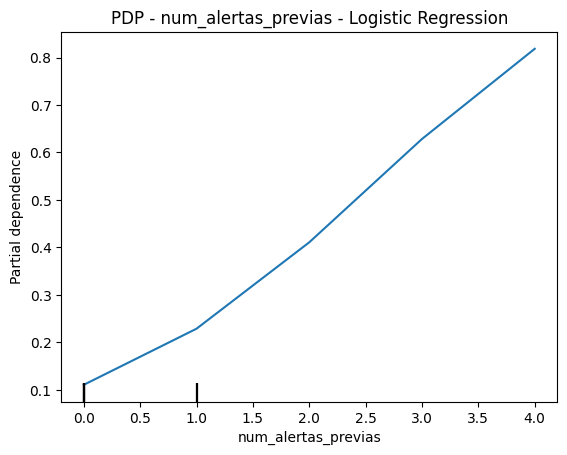

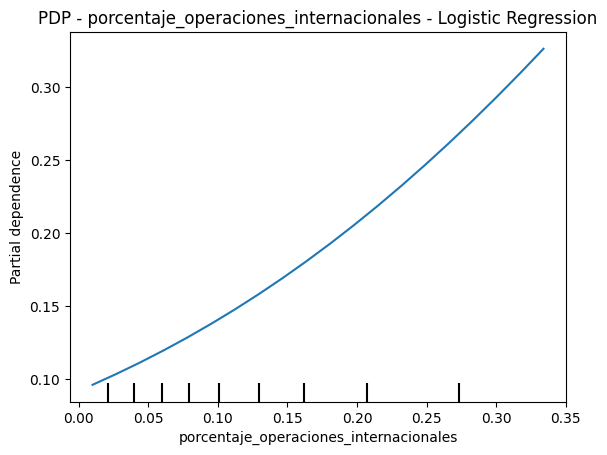

In [28]:
features_to_plot = ["ratio_ingresos_deuda", "num_alertas_previas", "porcentaje_operaciones_internacionales"]

for feat in features_to_plot:
    PartialDependenceDisplay.from_estimator(
        mejor_modelo,
        X_test,
        features=[feat],
        kind="average",
        grid_resolution=20
    )
    plt.title(f"PDP - {feat} - {mejor_nombre}")
    plt.show()


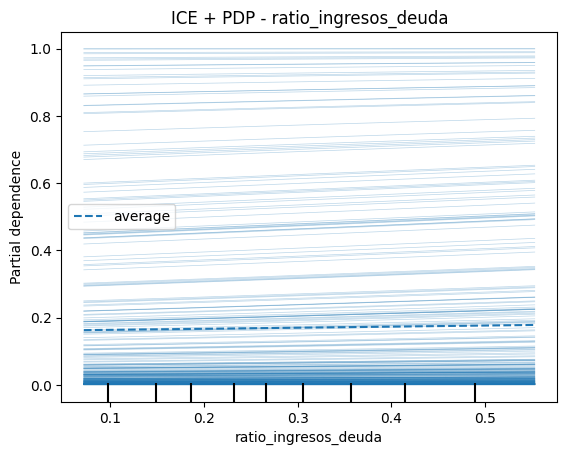

In [29]:
# ICE para una variable crítica de riesgo de auditoría
PartialDependenceDisplay.from_estimator(
    mejor_modelo,
    X_test.sample(min(300, len(X_test)), random_state=RANDOM_STATE),
    features=["ratio_ingresos_deuda"],
    kind="both",
    grid_resolution=20
)
plt.title("ICE + PDP - ratio_ingresos_deuda")
plt.show()


## 15. SHAP VALUES

SHAP significa **SHapley Additive exPlanations**. Se basa en teoría de juegos y asigna a cada variable una contribución a la predicción.

La idea fundamental:

$$Predicción = Valor\ base + \sum Contribuciones\ SHAP$$

Interpretación:

- SHAP positivo: empuja la predicción hacia mayor riesgo.
- SHAP negativo: empuja la predicción hacia menor riesgo.
- La magnitud indica intensidad de la contribución.

En banca, SHAP permite explicar:

- por qué un cliente fue clasificado como alto riesgo;
- qué variables explican una alerta AML;
- qué factores han aumentado o reducido el score;
- si el modelo usa variables de forma coherente con criterios expertos.

### 15.1 Precauciones al usar SHAP

SHAP es potente, pero no debe interpretarse de forma ingenua:

| Riesgo | Explicación |
|---|---|
| Correlación entre variables | SHAP puede repartir contribución entre variables correlacionadas |
| Causalidad | SHAP no demuestra causalidad |
| Datos transformados | Hay que mapear variables one-hot y escaladas |
| Coste computacional | Puede ser lento en datasets grandes |
| Explicación local ≠ regla global | Una explicación individual no resume todo el modelo |
| Variables proxy | SHAP puede revelar uso indirecto de variables sensibles |

In [30]:
# Matriz transformada para SHAP
X_train_trans = mejor_modelo.named_steps["preprocessor"].transform(X_train)
X_test_trans = mejor_modelo.named_steps["preprocessor"].transform(X_test)

# Convertir a DataFrame si no es demasiado grande
X_test_trans_df = pd.DataFrame(
    X_test_trans.toarray() if hasattr(X_test_trans, "toarray") else X_test_trans,
    columns=feature_names
)

X_train_trans_df = pd.DataFrame(
    X_train_trans.toarray() if hasattr(X_train_trans, "toarray") else X_train_trans,
    columns=feature_names
)

X_test_trans_df.head()

,importe_operacion,saldo_medio_cliente,num_operaciones_30d,importe_total_30d,antiguedad_cliente_meses,score_crediticio,ratio_ingresos_deuda,num_alertas_previas,dias_desde_ultima_revision,porcentaje_operaciones_internacionales,...,pais_riesgo_bajo,pais_riesgo_medio,producto_cuenta,producto_inversion,producto_prestamo,producto_tarjeta,producto_transferencia,segmento_riesgo_cliente_alto,segmento_riesgo_cliente_bajo,segmento_riesgo_cliente_medio
0,-0.294326,1.126880,-0.218109,-0.293551,0.695272,-1.137788,0.277331,-0.676879,0.766279,0.747069,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-0.251873,-0.433099,-0.218109,-0.394778,-1.200093,-0.796748,-1.434489,-0.676879,-0.395666,0.293009,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.358265,-0.691690,0.490549,-0.491656,-0.755867,-0.902588,-0.578579,-0.676879,-0.905788,1.002478,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.180436,-0.414242,0.018110,0.212379,-0.489331,0.238131,-0.761522,0.831767,-0.074478,-0.246188,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.350660,0.529075,1.671646,-0.491656,0.991423,-0.326349,2.041421,0.831767,0.105010,1.494377,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [31]:
if SHAP_AVAILABLE:
    model_core = mejor_modelo.named_steps["model"]
    sample_shap = X_test_trans_df.sample(500, random_state=RANDOM_STATE)

    # Para modelos de árbol, TreeExplainer suele ser eficiente.
    try:
        explainer = shap.TreeExplainer(model_core)
        shap_values = explainer.shap_values(sample_shap)
        print("SHAP calculado con TreeExplainer")
    except Exception:
        # Fallback genérico: más lento
        background = shap.sample(X_train_trans_df, 100, random_state=RANDOM_STATE)
        explainer = shap.Explainer(model_core.predict_proba, background)
        shap_values = explainer(sample_shap)
        print("SHAP calculado con Explainer genérico")
else:
    print("SHAP no disponible. Ejecuta: pip install shap")

SHAP calculado con Explainer genérico


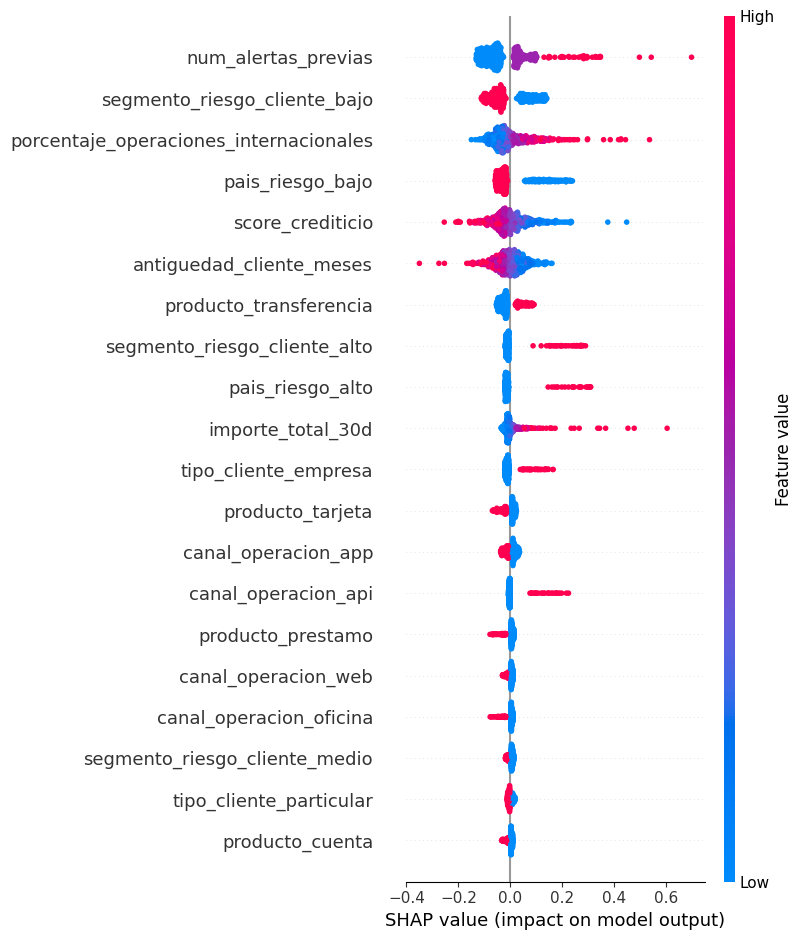

In [32]:
if SHAP_AVAILABLE:
    # Normalización de formatos SHAP según tipo de modelo/version
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    elif hasattr(shap_values, "values") and len(np.array(shap_values.values).shape) == 3:
        shap_values_plot = shap_values.values[:, :, 1]
    elif hasattr(shap_values, "values"):
        shap_values_plot = shap_values.values
    else:
        shap_values_plot = shap_values

    shap.summary_plot(shap_values_plot, sample_shap, show=True)
else:
    print("Bloque omitido porque SHAP no está instalado.")

### 15.2 Importancia global con SHAP

La importancia global SHAP suele calcularse como la media del valor absoluto de SHAP por variable.

,variable,mean_abs_shap
7,num_alertas_previas,0.0833
28,segmento_riesgo_cliente_bajo,0.0654
9,porcentaje_operaciones_internacionales,0.0592
20,pais_riesgo_bajo,0.0561
5,score_crediticio,0.0540
4,antiguedad_cliente_meses,0.0432
26,producto_transferencia,0.0336
27,segmento_riesgo_cliente_alto,0.0269
19,pais_riesgo_alto,0.0254
3,importe_total_30d,0.0241


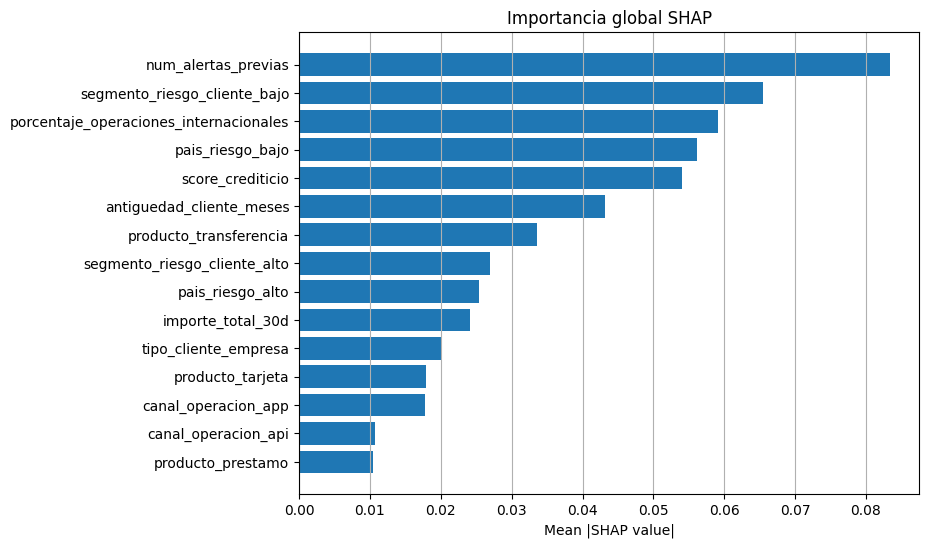

In [33]:
if SHAP_AVAILABLE:
    shap_importance = pd.DataFrame({
        "variable": sample_shap.columns,
        "mean_abs_shap": np.abs(shap_values_plot).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False)
    display(shap_importance.head(15).round(4))

    plt.figure(figsize=(8, 6))
    top_shap = shap_importance.head(15).sort_values("mean_abs_shap")
    plt.barh(top_shap["variable"], top_shap["mean_abs_shap"])
    plt.xlabel("Mean |SHAP value|")
    plt.title("Importancia global SHAP")
    plt.grid(axis="x")
    plt.show()
else:
    print("Bloque omitido porque SHAP no está instalado.")

### 15.3 Explicación local de un cliente

Una explicación local responde:

> ¿Por qué este cliente concreto tiene esta probabilidad estimada de default?

Esto es especialmente útil para:

- revisión manual de expedientes;
- comités de riesgo;
- explicación interna del score;
- validación de casos extremos;
- análisis de reclamaciones.

In [34]:
idx = 0
cliente = X_test.iloc[[idx]]
prob_cliente = mejor_modelo.predict_proba(cliente)[0, 1]
print("Probabilidad estimada de default:", round(prob_cliente, 4))
cliente

Probabilidad estimada de default: 0.0132


,importe_operacion,saldo_medio_cliente,num_operaciones_30d,importe_total_30d,antiguedad_cliente_meses,score_crediticio,ratio_ingresos_deuda,num_alertas_previas,dias_desde_ultima_revision,porcentaje_operaciones_internacionales,canal_operacion,tipo_cliente,pais_riesgo,producto,segmento_riesgo_cliente
1410,639.33,23840.14,17,4641.81,86.0,583.0,0.328,0,188.0,0.211,cajero,particular,bajo,prestamo,bajo


In [38]:
if SHAP_AVAILABLE:
    # Cliente concreto
    cliente_trans_df = pd.DataFrame(
        cliente_trans,
        columns=feature_names
    )

    shap_cliente = explainer(cliente_trans_df)

    # Extraer valores SHAP de forma robusta
    shap_values = shap_cliente.values

    # Si SHAP devuelve 3 dimensiones: (observaciones, variables, clases)
    if shap_values.ndim == 3:
        valores_cliente = shap_values[0, :, 1]   # clase positiva
    elif shap_values.ndim == 2:
        valores_cliente = shap_values[0, :]
    else:
        valores_cliente = shap_values.reshape(-1)

    # Asegurar que todo sea 1-dimensional
    valores_cliente = np.asarray(valores_cliente).ravel()
    valores_transformados = np.asarray(cliente_trans_df.iloc[0].values).ravel()
    feature_names_array = np.asarray(feature_names).ravel()

    # Comprobación de seguridad
    print("N variables:", len(feature_names_array))
    print("N valores transformados:", len(valores_transformados))
    print("N valores SHAP:", len(valores_cliente))

    # Crear tabla local
    local_df = pd.DataFrame({
        "variable": feature_names_array,
        "valor_transformado": valores_transformados,
        "shap_value": valores_cliente
    })

    local_df["abs_shap"] = local_df["shap_value"].abs()

    display(
        local_df
        .sort_values("abs_shap", ascending=False)
        .head(12)
        .round(4)
    )
else:
    print("Bloque omitido porque SHAP no está instalado.")

N variables: 30
N valores transformados: 30
N valores SHAP: 30


,variable,valor_transformado,shap_value,abs_shap
7,num_alertas_previas,-0.6769,-0.0734,0.0734
5,score_crediticio,-1.1378,0.0578,0.0578
28,segmento_riesgo_cliente_bajo,1.0000,-0.0474,0.0474
4,antiguedad_cliente_meses,0.6953,-0.0401,0.0401
9,porcentaje_operaciones_internacionales,0.7471,0.0317,0.0317
20,pais_riesgo_bajo,1.0000,-0.0309,0.0309
24,producto_prestamo,1.0000,-0.0285,0.0285
26,producto_transferencia,0.0000,-0.0230,0.0230
19,pais_riesgo_alto,0.0000,-0.0140,0.0140
11,canal_operacion_app,0.0000,0.0126,0.0126


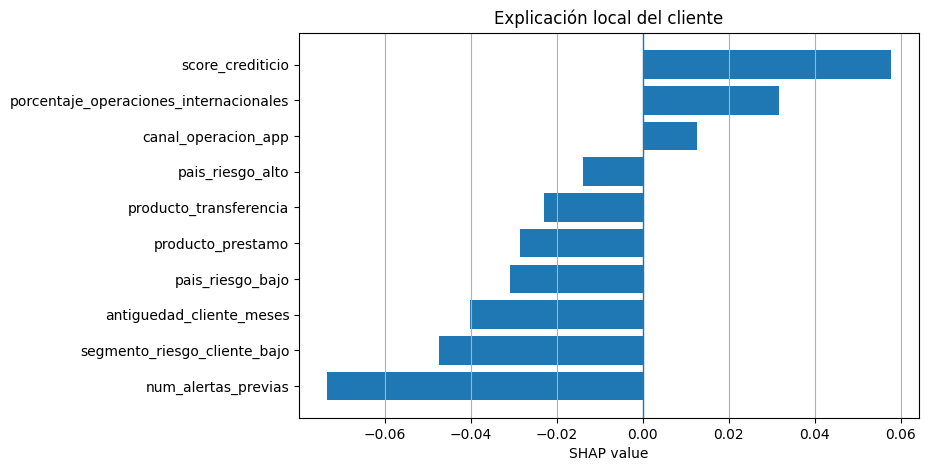

In [39]:
if SHAP_AVAILABLE:
    top_local = local_df.sort_values("abs_shap", ascending=False).head(10).sort_values("shap_value")
    plt.figure(figsize=(8, 5))
    plt.barh(top_local["variable"], top_local["shap_value"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("SHAP value")
    plt.title("Explicación local del cliente")
    plt.grid(axis="x")
    plt.show()
else:
    print("Bloque omitido porque SHAP no está instalado.")

## 16. INTERPRETACIÓN PARA AUDITORES: CÓMO REDACTAR CONCLUSIONES

Una buena conclusión de validación no debe decir solo “el modelo funciona bien”. Debe documentar evidencias.

Ejemplo de redacción:

> El modelo Gradient Boosting presenta un ROC-AUC superior al baseline logístico, manteniendo mejor PR-AUC en la clase default. La calibración presenta desviaciones moderadas en los deciles superiores, por lo que se recomienda calibración posterior mediante sigmoid/isotonic antes de usar probabilidades para pricing o provisiones. La importancia por permutación y SHAP identifican como principales factores explicativos el ratio deuda-ingresos, la mora reciente y las consultas de crédito, coherentes con criterio experto. No obstante, debe monitorizarse mensualmente el PSI del score y revisar estabilidad por segmento.

### 16.1 Checklist de auditoría del modelo

| Área | Pregunta de auditoría | Evidencia esperada |
|---|---|---|
| Datos | ¿Las variables estaban disponibles en el momento de decisión? | Diccionario de datos, corte temporal |
| Target | ¿La definición de default/fraude/alerta es consistente? | Definición funcional y técnica |
| Partición | ¿Train/test respetan tiempo o estratificación? | Código y distribución de eventos |
| Métricas | ¿Se usan métricas adecuadas al desbalanceo? | ROC-AUC, PR-AUC, recall, matriz |
| Umbral | ¿El threshold está justificado? | Análisis coste-beneficio |
| Calibración | ¿Las probabilidades son fiables? | Calibration curve, Brier |
| Interpretabilidad | ¿Se pueden explicar predicciones? | SHAP, PDP, permutation importance |
| Estabilidad | ¿Hay drift? | PSI, métricas por periodo |
| Sesgos | ¿Hay impacto desigual por segmento? | Métricas segmentadas |
| Gobierno | ¿Hay documentación y monitorización? | Ficha/model card |

## 17. EVALUACIÓN POR SEGMENTOS

En banca es importante comprobar que el modelo no funciona bien solo en promedio. Debe revisarse el rendimiento por segmentos relevantes:

- tipo de cliente;
- canal;
- producto;
- territorio;
- antigüedad;
- rango de ingresos;
- nivel de riesgo.

In [40]:
def metricas_por_segmento(df_test, y_true, y_prob, segmento_col, threshold=0.5):
    temp = df_test.copy()
    temp["y_true"] = y_true.values
    temp["y_prob"] = y_prob
    temp["y_pred"] = (y_prob >= threshold).astype(int)

    rows = []
    for seg, data in temp.groupby(segmento_col):
        if data["y_true"].nunique() < 2:
            auc = np.nan
            prauc = np.nan
        else:
            auc = roc_auc_score(data["y_true"], data["y_prob"])
            prauc = average_precision_score(data["y_true"], data["y_prob"])
        rows.append({
            "segmento": seg,
            "n": len(data),
            "tasa_evento": data["y_true"].mean(),
            "tasa_alerta": data["y_pred"].mean(),
            "precision": precision_score(data["y_true"], data["y_pred"], zero_division=0),
            "recall": recall_score(data["y_true"], data["y_pred"], zero_division=0),
            "roc_auc": auc,
            "pr_auc": prauc
        })
    return pd.DataFrame(rows)

metricas_segmento = metricas_por_segmento(X_test, y_test, y_prob_best, "segmento_riesgo_cliente", threshold=umbral_optimo)
metricas_segmento.round(4)


,segmento,n,tasa_evento,tasa_alerta,precision,recall,roc_auc,pr_auc
0,alto,364,0.2253,0.3956,0.5556,0.9756,0.9648,0.9299
1,bajo,2907,0.0361,0.0561,0.5337,0.8286,0.9143,0.7854
2,medio,1229,0.0789,0.1318,0.5617,0.9381,0.9669,0.8781


In [41]:
metricas_canal = metricas_por_segmento(X_test, y_test, y_prob_best, "canal_operacion", threshold=umbral_optimo)
metricas_canal.round(4)

,segmento,n,tasa_evento,tasa_alerta,precision,recall,roc_auc,pr_auc
0,api,209,0.1340,0.2297,0.5833,1.0000,0.9933,0.9655
1,app,1929,0.0575,0.0938,0.5525,0.9009,0.9518,0.8602
2,cajero,573,0.0663,0.1204,0.4928,0.8947,0.9500,0.8237
3,oficina,555,0.0595,0.1009,0.5357,0.9091,0.9297,0.8212
4,web,1234,0.0600,0.0932,0.5739,0.8919,0.9420,0.8549


## 18. MODEL CARD / FICHA DEL MODELO

Una ficha de modelo ayuda a documentar de forma clara el uso, límites y evidencias de validación.

In [42]:
model_card = {
    "Nombre del modelo": mejor_nombre,
    "Caso de uso": "Detección de operaciones con riesgo de auditoría bancaria",
    "Población objetivo": "Operaciones bancarias sujetas a revisión, control interno o auditoría",
    "Variable objetivo": "riesgo_auditoria",
    "Métrica principal": "ROC-AUC y PR-AUC",
    "Umbral recomendado": round(float(umbral_optimo), 2),
    "Coste FP asumido": COSTE_FP,
    "Coste FN asumido": COSTE_FN,
    "PSI score train-test": round(float(psi_score), 4),
    "Variables críticas": ", ".join(perm_df.head(5)["variable"].tolist()),
    "Limitaciones": "Dataset sintético; requiere validación temporal, calibración, revisión de sesgos y contraste experto antes de producción",
    "Monitorización": "Métricas periódicas, PSI del score, PSI de variables, calibración y análisis por canal, producto y segmento de riesgo"
}

pd.DataFrame(model_card.items(), columns=["Campo", "Descripción"])


,Campo,Descripción
0,Nombre del modelo,Logistic Regression
1,Caso de uso,Detección de operaciones con riesgo de auditor...
2,Población objetivo,"Operaciones bancarias sujetas a revisión, cont..."
3,Variable objetivo,riesgo_auditoria
4,Métrica principal,ROC-AUC y PR-AUC
5,Umbral recomendado,0.6
6,Coste FP asumido,500
7,Coste FN asumido,8000
8,PSI score train-test,0.0028
9,Variables críticas,"pais_riesgo, num_alertas_previas, segmento_rie..."


## 19. CASUÍSTICAS ESPECÍFICAS PARA AUDITORÍA BANCARIA

### 19.1 Default crediticio

Aspectos clave:

- target definido a 90 días de mora o criterio interno;
- ventana de observación y ventana de performance;
- evitar variables posteriores a la concesión;
- revisar calibración para PD;
- monitorizar estabilidad macroeconómica.

### 19.2 Fraude

Aspectos clave:

- clase extremadamente minoritaria;
- PR-AUC más relevante que accuracy;
- coste operativo de alertas;
- necesidad de explicaciones rápidas para analistas;
- drift muy frecuente por cambio de patrones.

### 19.3 AML

Aspectos clave:

- muchas alertas falsas;
- revisión manual intensiva;
- trazabilidad completa;
- explicación de reglas/modelos;
- sensibilidad regulatoria alta.

### 19.4 Churn

Aspectos clave:

- optimización económica por campañas;
- uplift y coste comercial;
- explicación comercial del abandono;
- sesgo por campañas previas.

### 19.5 Riesgo operativo

Aspectos clave:

- baja frecuencia;
- severidad elevada;
- histórico escaso;
- utilidad de modelos interpretables y reglas híbridas.

## 20. ERRORES FRECUENTES QUE DEBE DETECTAR UN AUDITOR

| Error | Consecuencia | Cómo detectarlo |
|---|---|---|
| Evaluar con accuracy en datos desbalanceados | Sensación falsa de buen modelo | Comparar con tasa base y PR-AUC |
| Usar test para ajustar hiperparámetros | Optimismo en resultados | Revisar pipeline de validación |
| No calibrar probabilidades | Decisiones económicas mal cuantificadas | Curva de calibración, Brier |
| Elegir threshold 0.5 sin justificar | Decisiones subóptimas | Análisis coste-beneficio |
| Ignorar drift | Degradación silenciosa | PSI y performance temporal |
| Explicar solo con importancia de árboles | Interpretación sesgada | Permutation + SHAP |
| No evaluar segmentos | Riesgo de discriminación o inestabilidad | Métricas por segmento |
| Variables con leakage | Modelo irrealmente bueno | Revisión temporal de variables |
| Confundir correlación con causalidad | Decisiones mal justificadas | Revisión metodológica |
| No documentar limitaciones | Riesgo de gobierno del modelo | Model card y validación independiente |

# 21. EJERCICIOS FINALES

A continuación se proponen **10 ejercicios** para resolver con nuevos datos sintéticos. La idea es que el alumno/a aplique evaluación, interpretación y XAI en un contexto bancario.

Cada ejercicio debe incluir:

- código;
- tablas de resultados;
- gráficos cuando proceda;
- interpretación escrita como auditor/a;
- conclusiones y recomendaciones.

In [ ]:
# ============================================================
# Nuevo dataset para ejercicios: fraude transaccional
# ============================================================
N2 = 8000

importe = np.random.lognormal(mean=3.5, sigma=1.1, size=N2).clip(1, 5000)
hora = np.random.randint(0, 24, N2)
num_trans_1h = np.random.poisson(2.2, N2).clip(0, 25)
pais_riesgo = np.random.binomial(1, 0.12, N2)
dispositivo_nuevo = np.random.binomial(1, 0.18, N2)
cliente_antiguedad_meses = np.random.exponential(38, N2).clip(1, 240)
transacciones_previas = np.random.poisson(35, N2).clip(0, 300)
canal = np.random.choice(["POS", "Online", "ATM", "Transferencia"], size=N2, p=[0.45, 0.32, 0.12, 0.11])
segmento_cliente = np.random.choice(["Retail", "Premium", "Pyme"], size=N2, p=[0.72, 0.12, 0.16])

z2 = (
    -5.6
    + 0.0007 * importe
    + 0.12 * num_trans_1h
    + 1.25 * pais_riesgo
    + 0.95 * dispositivo_nuevo
    - 0.006 * cliente_antiguedad_meses
    - 0.004 * transacciones_previas
    + np.where((hora <= 5), 0.65, 0)
    + np.where(canal == "Online", 0.55, 0)
    + np.where(canal == "Transferencia", 0.35, 0)
    + np.random.normal(0, 0.6, N2)
)
prob_fraude = 1 / (1 + np.exp(-z2))
fraude = np.random.binomial(1, prob_fraude)

df_fraude = pd.DataFrame({
    "importe": importe.round(2),
    "hora": hora,
    "num_trans_1h": num_trans_1h,
    "pais_riesgo": pais_riesgo,
    "dispositivo_nuevo": dispositivo_nuevo,
    "cliente_antiguedad_meses": cliente_antiguedad_meses.round(0).astype(int),
    "transacciones_previas": transacciones_previas,
    "canal": canal,
    "segmento_cliente": segmento_cliente,
    "fraude": fraude
})

print(df_fraude.shape)
print("Tasa de fraude:", df_fraude["fraude"].mean().round(4))
df_fraude.head()

## Ejercicio 1 — Evaluación básica de modelos

Con `df_fraude`:

1. Divide los datos en train/test con estratificación.
2. Entrena una regresión logística y un Random Forest.
3. Calcula accuracy, precision, recall, F1, ROC-AUC y PR-AUC.
4. Explica qué métrica sería más importante para fraude y por qué.

In [ ]:
# Escribe aquí tu solución

## Ejercicio 2 — Matriz de confusión e interpretación bancaria

Para el mejor modelo del ejercicio 1:

1. Calcula la matriz de confusión con threshold 0.50.
2. Interpreta TP, FP, FN y TN en lenguaje de auditoría bancaria.
3. Explica qué error es más grave en fraude y qué impacto operativo tiene.

In [ ]:
# Escribe aquí tu solución

## Ejercicio 3 — Selección de threshold por coste

Supón:

- coste de revisar una falsa alerta: 20 €;
- coste de dejar pasar un fraude: 1.500 €.

Calcula el coste total para thresholds entre 0.01 y 0.50. Selecciona el threshold óptimo y justifícalo.

In [ ]:
# Escribe aquí tu solución

## Ejercicio 4 — Curvas ROC y Precision-Recall

Dibuja las curvas ROC y Precision-Recall para los modelos entrenados.

Preguntas:

1. ¿Qué modelo tiene mejor ranking global?
2. ¿Qué modelo es preferible si la clase fraude es minoritaria?
3. ¿Puede un modelo tener buen ROC-AUC pero PR-AUC mediocre?

In [ ]:
# Escribe aquí tu solución

## Ejercicio 5 — Calibración de probabilidades

Para el modelo elegido:

1. Dibuja la curva de calibración.
2. Calcula Brier score y log-loss.
3. Aplica `CalibratedClassifierCV` con método `sigmoid`.
4. Compara antes y después.
5. Explica si usarías la probabilidad como score económico.

In [ ]:
# Escribe aquí tu solución

## Ejercicio 6 — Permutation importance

Calcula permutation importance sobre test usando ROC-AUC como métrica.

Preguntas:

1. ¿Qué variables son más importantes?
2. ¿Coinciden con intuición bancaria?
3. ¿Qué limitaciones tiene esta técnica si hay variables correlacionadas?

In [ ]:
# Escribe aquí tu solución

## Ejercicio 7 — PDP e ICE

Genera PDP para:

- `importe`;
- `num_trans_1h`;
- `cliente_antiguedad_meses`.

Después genera ICE para `importe`.

Interpreta si el comportamiento del modelo es razonable.

In [ ]:
# Escribe aquí tu solución

## Ejercicio 8 — SHAP global

Si tienes SHAP instalado:

1. Calcula SHAP values para una muestra de test.
2. Genera un summary plot.
3. Calcula la importancia global media absoluta.
4. Redacta una interpretación para un informe de auditoría.

Si SHAP no está instalado, explica qué comandos usarías y qué esperarías encontrar.

In [ ]:
# Escribe aquí tu solución

## Ejercicio 9 — SHAP local / explicación individual

Selecciona una transacción con probabilidad alta de fraude.

1. Muestra sus variables originales.
2. Calcula sus principales contribuciones SHAP.
3. Explica por qué el modelo la considera sospechosa.
4. Indica si la explicación es suficiente para revisión manual.

In [ ]:
# Escribe aquí tu solución

## Ejercicio 10 — Informe final de validación

Redacta un informe breve con:

1. modelo seleccionado;
2. métricas principales;
3. threshold recomendado;
4. calibración;
5. variables explicativas principales;
6. riesgos detectados;
7. controles de monitorización;
8. conclusión final de auditoría.

In [ ]:
# Escribe aquí tu solución

# 22. RESUMEN FINAL

En este notebook se han trabajado los elementos esenciales para evaluar e interpretar modelos en auditoría bancaria:

- métricas de clasificación;
- curvas ROC y Precision-Recall;
- selección de umbral por coste;
- calibración de probabilidades;
- validación cruzada;
- estabilidad mediante PSI;
- interpretación global y local;
- permutation importance;
- PDP e ICE;
- SHAP values;
- evaluación por segmentos;
- documentación mediante model card.

La idea central es que un modelo bancario no debe defenderse solo por su rendimiento, sino por su **utilidad, estabilidad, explicabilidad, trazabilidad y adecuación al riesgo**.